
📥 Schritt 1: Datenimport & Cleaning
[REPORT] cleaned Aj_Someringii: shape=(370, 141)
[REPORT] cleaned Amur_Tiger: shape=(605, 133)
[REPORT] cleaned Bengal_tiger: shape=(586, 133)
[REPORT] cleaned cheetah: shape=(781, 141)
[REPORT] cleaned Eurasian_Otter: shape=(628, 214)
[REPORT] cleaned Giant_Panda: shape=(523, 129)
[REPORT] cleaned Jubatus: shape=(566, 141)
[REPORT] cleaned Lowlandtapir: shape=(426, 126)
[REPORT] cleaned Mountain_Lion: shape=(535, 138)
[REPORT] cleaned White_Rhino: shape=(1273, 117)
[SUCCESS] clean_all completed.

✂️ Schritt 2: Splitting & Fold-Zuordnung
✅ Fold-Methode verwendet: stratified_group
Fold
0     98
1    112
2     90

📊 aj_someringii – train – 300 Zeilen | 20 Individuen | 43 Trails
sex
m    153
f    147

📊 aj_someringii – test – 70 Zeilen | 5 Individuen | 10 Trails
sex
f    42
m    28

📊 aj_someringii – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ aj_someringii gespeichert (csv & parquet)
✅ Fold-Methode verwendet: stratified_group
Fold
0

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:213: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["Fold"] = fold_ids
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Fold"] = fold_ids



✅ Fold-Methode verwendet: stratified_group
📊 Fold-Verteilung:
Fold
0    123
1    142
2    130
Name: count, dtype: int64
✔️ Fold-Spalte in eurasian_otter schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    123
1    142
2    130

📊 eurasian_otter – train – 395 Zeilen | 27 Individuen | 54 Trails
sex
f    220
m    175

📊 eurasian_otter – test – 152 Zeilen | 14 Individuen | 19 Trails
sex
f    86
m    66

📊 eurasian_otter – inference – 81 Zeilen | 1 Individuen | 8 Trails
sex
unknown    81

✅ eurasian_otter gespeichert (csv & parquet)
✅ Fold-Methode verwendet: stratified_group
Fold
0     88
1    144
2    172

📊 giant_panda – train – 404 Zeilen | 33 Individuen | 61 Trails
sex
f    238
m    166

📊 giant_panda – test – 119 Zeilen | 9 Individuen | 16 Trails
sex
f    63
m    56

📊 giant_panda – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ giant_panda gespeichert (csv & parquet)
✅ Fold-Methode verwendet: stratified_group
Fold
0    153
1    147


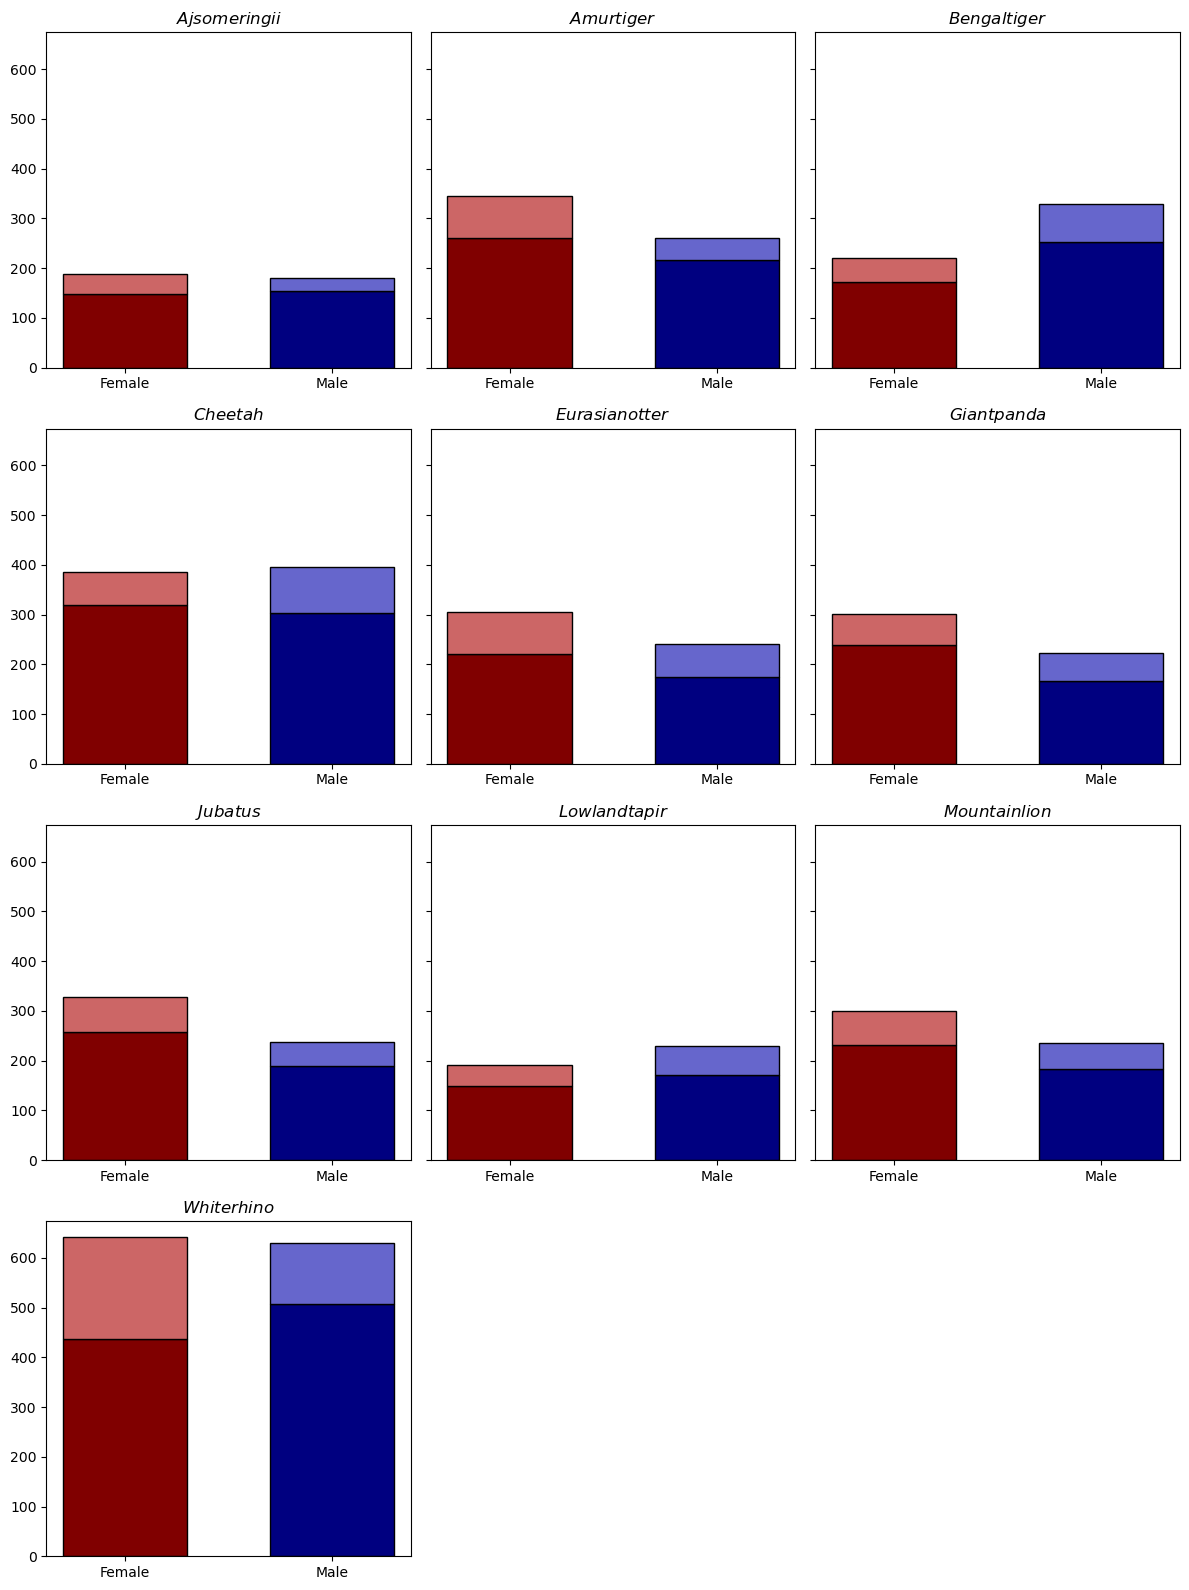

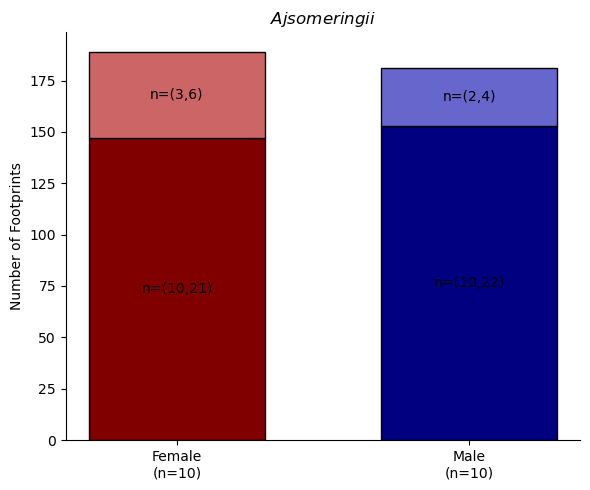

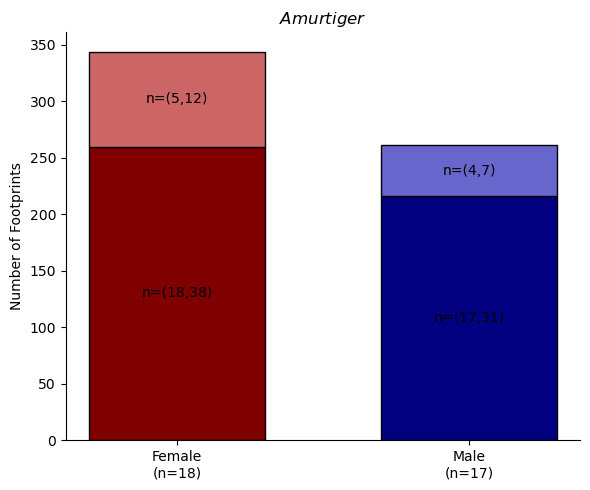

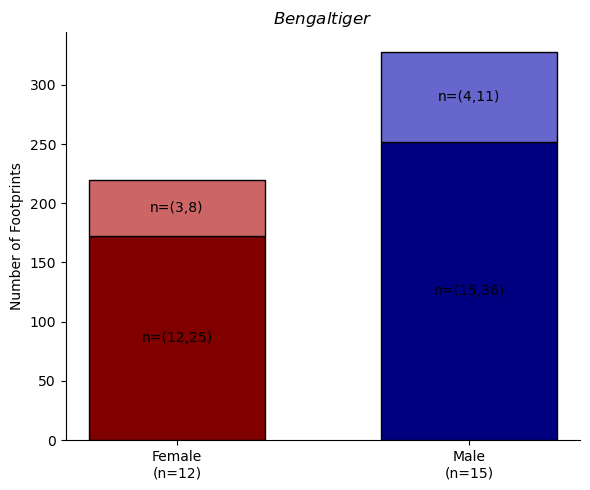

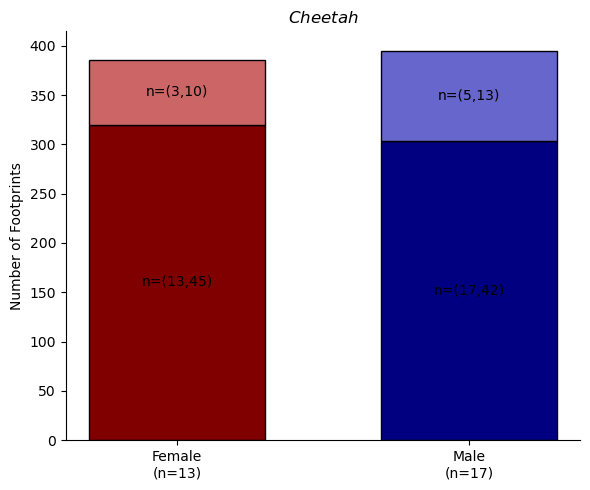

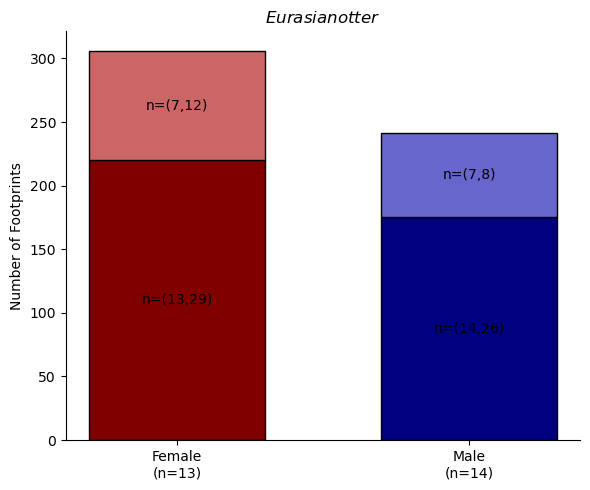

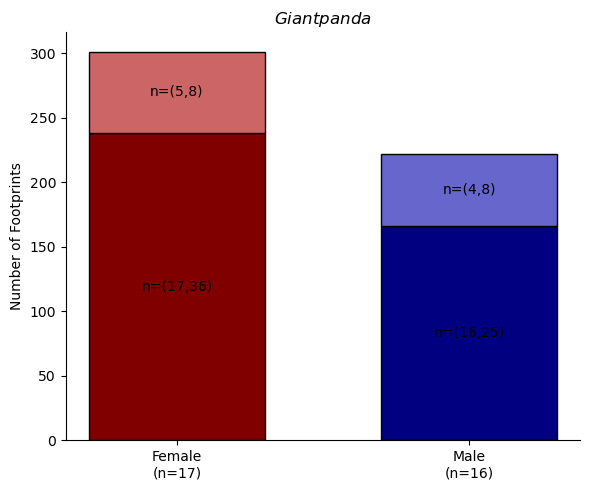

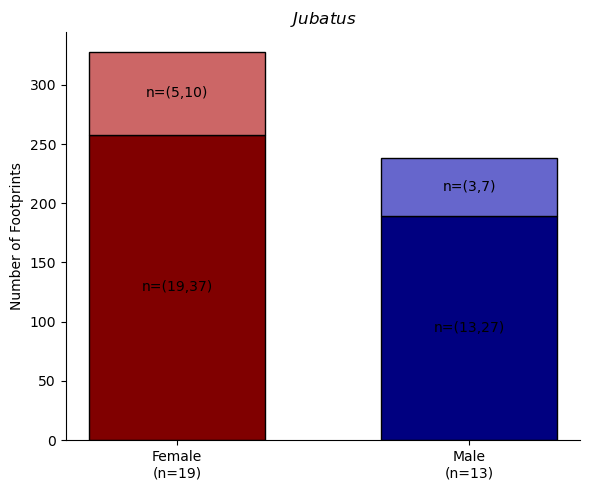

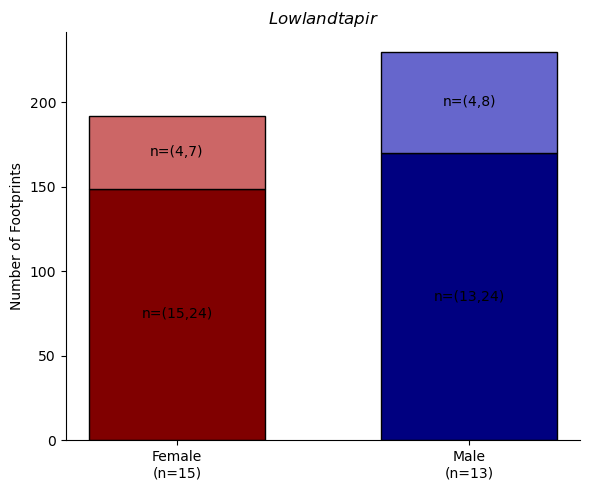

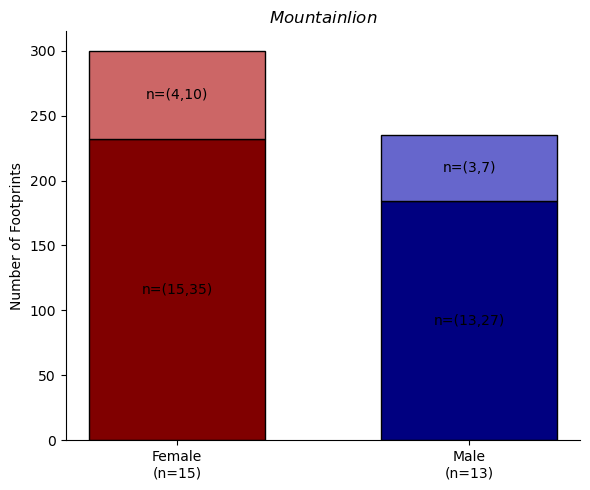

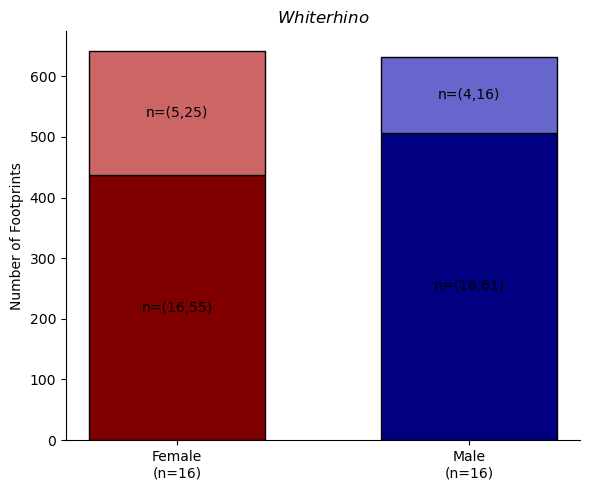

In [1]:
# %% [code]
from pathlib import Path
import pandas as pd
import numpy as np
import ast
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from sklearn.model_selection import ParameterSampler

from FIT_python.pipeline_sex.pipeline_wrapper_sex import PipelineWrapper
from FIT_python.config import RESULTS_DATA_DIR

# 1) Prepare (Clean → Split → Summary)
prep = PipelineWrapper(
    model_keys=["log_reg"],  # Dummy
    impute_method=None,
    outlier_method=None,
    scaler_method=None,
    reduce_pre_method=None,
    reduce_post_method=None,
    fs_method=None,
    fs_k=None,
)
prep.prepare()



In [2]:
import shutil
from FIT_python.pipeline_sex.pipeline_wrapper_sex import _cache_dir

# Cache-Verzeichnis komplett entfernen
shutil.rmtree(_cache_dir)
print(f"Cache gelöscht: {_cache_dir}")


Cache gelöscht: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pipeline_cache


In [ ]:
# %% [code] RandomizedGridSearchCV mit Standard-Metriken & Custom-Auswertung (aggregiert)
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from tqdm.auto import tqdm
from tqdm_joblib import tqdm_joblib
import joblib
from functools import reduce
import operator

from sklearn.metrics import accuracy_score, balanced_accuracy_score
from FIT_python.pipeline_sex.transform_wrapper                import NumericTransformer
from FIT_python.pipeline_sex.feature_selection_wrapper        import FeatureSelectionTransformer
from FIT_python.pipeline_sex.outlier_wrapper                  import OutlierCleanerTransformer
from FIT_python.pipeline_sex.feature_scaler_wrapper           import FeatureScalerTransformer
from FIT_python.pipeline_sex.dimensionality_reduction_wrapper import DimensionalityReducerTransformer
from FIT_python.pipeline_sex.models                           import MODELS
from FIT_python.pipeline_sex.grouped_metrics                  import individual_accuracies, individual_majority_stats
from FIT_python.config                                        import SPLITS_DIR, RESULTS_DATA_DIR

import warnings
from sklearn.exceptions import ConvergenceWarning

# Warnings nur einmal
warnings.filterwarnings("once", category=ConvergenceWarning, message="Objective did not converge.*")
warnings.filterwarnings("once", category=UserWarning,       message="X does not have valid feature names.*")

# 1) Modell‐Keys
model_keys = [
    "logreg_l2","logreg_l1",
    "rf_small","rf_med","rf_large",
    "et_med","et_sm",
    "knn_3","knn_5","knn_7",
    "svm_linear","svm_rbf",
    "xgb_std","xgb_hist",
    "lgbm_std","lgbm_md10",
    "catb_std","catb_fast","lda",
]

# 2) Param‐Räume (inkl. PCA/UMAP‐ & Outlier‐Hyperparams)
param_distributions = {
    # Feature Selection (inkl. RF)
    "select__method":          [None, "forward", "lasso", "variance", "random_forest"],
    "select__k":               [5, 20, 50],

    # Outlier‐Cleaning
    "outlier__method":         [None, "clip", "zscore"],
    "outlier__lower_quantile": [0.01, 0.05],
    "outlier__upper_quantile": [0.90, 0.95],
    "outlier__z_thresh":       [2.0, 3.0],

    # Scaling
    "scale__method":           [None, "standard", "robust", "minmax"],

    # DimRed Pre
    "reduce_pre__method":        [None, "pca", "umap"],
    "reduce_pre__n_components":  [2, 10],
    "reduce_pre__n_neighbors":   [5, 10, 15, 30, 50],   # ← mehr Nachbarn
    "reduce_pre__min_dist":      [0.1, 0.5],
    "reduce_pre__whiten":        [False, True],

    # DimRed Post
    "reduce_post__method":       [None, "pca", "umap"],
    "reduce_post__n_components": [2, 10],
    "reduce_post__n_neighbors":  [5, 10, 15, 30, 50],   # ← mehr Nachbarn
    "reduce_post__min_dist":     [0.1, 0.5],
    "reduce_post__whiten":       [False, True],

    # Classifier
    "clf": [MODELS[k] for k in model_keys],
}

# 3) Wie groß ist der Suchraum?
lengths = {k: len(v) for k,v in param_distributions.items()}
total_combinations = reduce(operator.mul, lengths.values(), 1)

print("Anzahl der Werte pro Parameter:")
for k, l in lengths.items():
    print(f"  {k:25s}: {l}")
print(f"\n→ Gesamtzahl aller Hyper‐Kombinationen: {total_combinations:,}")


# 3) Ergebnis-Ordner
base_dir = Path(RESULTS_DATA_DIR) / "random_search_standard_metrics"
base_dir.mkdir(parents=True, exist_ok=True)

# Unterordner für Best-Modelle je Metrik
metrics = [
    "maj_test_pct",
    "balanced_test_acc",      # <-- hier
    "accuracy_test",
    "mean_test_neg_log_loss"
]
for m in metrics:
    (base_dir / f"best_{m}").mkdir(exist_ok=True)

# 4) Scoring-Dict
scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "neg_log_loss":      "neg_log_loss",
}

# 5) Sammel-Listen
raw_records  = []
best_records = []

# 6) Loop über Spezies
for species_dir in tqdm(sorted(Path(SPLITS_DIR).iterdir()), desc="Species"):
    if not species_dir.is_dir(): 
        continue
    species = species_dir.name
    print(f"\n🔄 Processing species: {species}")

    # 6.1) Train/Test laden & Fold entfernen
    df_train = (pd.read_parquet(species_dir / "train.parquet")
                  .query("sex in ['f','m']")
                  .drop(columns=["Fold"], errors="ignore"))
    df_test  = (pd.read_parquet(species_dir / "test.parquet")
                  .query("sex in ['f','m']")
                  .drop(columns=["Fold"], errors="ignore"))

    # 🔍 Feature-Spalten abhängig von Spezies auswählen
    if species == "eurasian_otter":
        feature_cols = [
            c for c in df_train.columns 
            if c.startswith(("dist", "ang", "t")) and pd.api.types.is_numeric_dtype(df_train[c])
        ]
    else:
        feature_cols = [
            c for c in df_train.columns[5:] 
            if pd.api.types.is_numeric_dtype(df_train[c])
        ]
    print(f"  → {len(feature_cols)} numerische Features")

    # 6.2) Features, Ziel & IDs
    X_tr, y_tr, ids_tr = (
        df_train[feature_cols],
        df_train["sex"].map({"f":0,"m":1}).values,
        df_train["individual_id"].values
    )
    X_te, y_te, ids_te = (
        df_test[feature_cols],
        df_test["sex"].map({"f":0,"m":1}).values,
        df_test["individual_id"].values
    )

    # 6.3) Pipeline
    steps = [
        ("transform",  NumericTransformer()),
        ("select",     FeatureSelectionTransformer(method="forward", k=1)),
        ("outlier",    OutlierCleanerTransformer(method="clip")),
        ("scale",      FeatureScalerTransformer(method="standard")),
        ("reduce_pre", DimensionalityReducerTransformer(method=None, n_components=1)),
        ("reduce_post",DimensionalityReducerTransformer(method=None, n_components=1)),
        ("clf",        MODELS["rf_small"]),
    ]
    pipe = Pipeline(steps)

    # 6.4) RandomizedSearchCV
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=300,      # kleiner Testdurchgang
        scoring=scoring,
        refit=False,
        cv=5,
        n_jobs=-1,
        random_state=42,
        verbose=1,
    )

# 6.5) Fit mit tqdm (dynamisch berechnete Gesamt-Anzahl an Fits)
    n_iter = search.n_iter
    # wenn cv ein Integer ist, nutzen wir es direkt, sonst versuchen wir n_splits zu lesen
    folds  = search.cv if isinstance(search.cv, int) else getattr(search.cv, "n_splits", len(list(search.cv)))
    total_fits = n_iter * folds

    with tqdm_joblib(tqdm(desc=f"{species} RS-CV", total=total_fits, leave=False)):
        search.fit(X_tr, y_tr)

    # 6.6) CV-Ergebnisse & Custom-Metriken sammeln
    cv_res = search.cv_results_
    for i, params in enumerate(cv_res["params"]):
        record = {
            "species":                     species,
            "mean_test_accuracy":          cv_res["mean_test_accuracy"][i],
            "mean_test_balanced_accuracy": cv_res["mean_test_balanced_accuracy"][i],
            "mean_test_neg_log_loss":      cv_res["mean_test_neg_log_loss"][i],
            **params
        }
        # kompletter Re-Fit für Custom-Metriken
        mdl = clone(pipe).set_params(**params).fit(X_tr, y_tr)
        y_tr_pred = mdl.predict(X_tr)
        y_te_pred = mdl.predict(X_te)
        y_all_true = np.concatenate([y_tr, y_te])
        y_all_pred = np.concatenate([y_tr_pred, y_te_pred])
        ids_all     = np.concatenate([ids_tr, ids_te])

        fem_tr, mal_tr, bal_tr    = individual_accuracies(y_tr, y_tr_pred, ids_tr)
        fem_te, mal_te, bal_te    = individual_accuracies(y_te, y_te_pred, ids_te)
        ct_tr, wr_tr, pct_tr      = individual_majority_stats(y_tr, y_tr_pred, ids_tr)
        ct_te, wr_te, pct_te      = individual_majority_stats(y_te, y_te_pred, ids_te)
        fem_all, mal_all, bal_all = individual_accuracies(y_all_true, y_all_pred, ids_all)
        ct_all, wr_all, pct_all   = individual_majority_stats(y_all_true, y_all_pred, ids_all)
                # Accuracy & Balanced Accuracy
        acc_tr  = accuracy_score(y_tr,  y_tr_pred)
        bal_tr  = balanced_accuracy_score(y_tr,  y_tr_pred)
        acc_te  = accuracy_score(y_te,  y_te_pred)
        bal_te  = balanced_accuracy_score(y_te,  y_te_pred)

        # Neu: Full-Dataset Accuracy & Balanced Accuracy
        acc_all = accuracy_score(y_all_true, y_all_pred)
        bal_all = balanced_accuracy_score(y_all_true, y_all_pred)

        

        record.update({
            "female_train_acc":   fem_tr, "male_train_acc":   mal_tr, "balanced_train_acc": bal_tr, "accuracy_train":          acc_tr,
            "female_test_acc":    fem_te, "male_test_acc":    mal_te, "balanced_test_acc":  bal_te, "accuracy_test":          acc_te,
            "female_full_acc":    fem_all,"male_full_acc":    mal_all,"balanced_full_acc":  bal_all,"accuracy_full":          acc_all,
            "maj_train_count":    ct_tr, "maj_train_wrong":  wr_tr, "maj_train_pct":      pct_tr,
            "maj_test_count":     ct_te, "maj_test_wrong":   wr_te, "maj_test_pct":       pct_te,
            "maj_full_count":     ct_all,"maj_full_wrong":   wr_all,"maj_full_pct":       pct_all,
        })
        raw_records.append(record)

# 6.7) Beste Modelle je Metrik speichern UND Joblib dump
    df_eval = pd.DataFrame([r for r in raw_records if r["species"] == species])
    for metric in metrics:
        # Index und Parameter des besten Runs finden
        best_idx    = df_eval[metric].idxmax()
        best_params = cv_res["params"][best_idx]
        # Erstelle das Record-Dict für best_records
        best_record = df_eval.loc[best_idx].to_dict()
        best_record["best_metric"] = metric

        # Finales Modell trainieren und speichern
        best_pipe = clone(pipe).set_params(**best_params).fit(X_tr, y_tr)
        out_path = base_dir / f"best_{metric}" / f"{species}.joblib"
        joblib.dump(best_pipe, out_path)
        print(f"✅ Modell für Spezies '{species}', Kriterium '{metric}' gespeichert unter:\n   {out_path}")

        # **Ganz wichtig**: best_record in best_records einfuegen
        best_records.append(best_record)

    # → CSVs direkt aktualisieren (innerhalb des Species-Loops)
    all_csv  = base_dir / "all_results.csv"
    best_csv = base_dir / "best_models.csv"
    pd.DataFrame(raw_records).to_csv(all_csv,  index=False)
    pd.DataFrame(best_records).to_csv(best_csv, index=False)
    print(f"💾 CSV-Dateien aktualisiert:\n   • alle Roh-Ergebnisse → {all_csv}\n   • beste Modelle      → {best_csv}\n")



Anzahl der Werte pro Parameter:
  select__method           : 5
  select__k                : 3
  outlier__method          : 3
  outlier__lower_quantile  : 2
  outlier__upper_quantile  : 2
  outlier__z_thresh        : 2
  scale__method            : 4
  reduce_pre__method       : 3
  reduce_pre__n_components : 2
  reduce_pre__n_neighbors  : 5
  reduce_pre__min_dist     : 2
  reduce_pre__whiten       : 2
  reduce_post__method      : 3
  reduce_post__n_components: 2
  reduce_post__n_neighbors : 5
  reduce_post__min_dist    : 2
  reduce_post__whiten      : 2
  clf                      : 19

→ Gesamtzahl aller Hyper‐Kombinationen: 393,984,000


Species:   0%|          | 0/10 [00:00<?, ?it/s]


🔄 Processing species: aj_someringii
  → 136 numerische Features


aj_someringii RS-CV:   0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

...

c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.113e-02, tolerance: 9.415e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.275e-02, tolerance: 9.415e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale

✅ Modell für Spezies 'amur_tiger', Kriterium 'mean_test_neg_log_loss' gespeichert unter:
   C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\random_search_standard_metrics\best_mean_test_neg_log_loss\amur_tiger.joblib
💾 CSV-Dateien aktualisiert:
   • alle Roh-Ergebnisse → C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\random_search_standard_metrics\all_results.csv
   • beste Modelle      → C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\random_search_standard_metrics\best_models.csv


🔄 Processing species: bengal_tiger
  → 128 numerische Features


bengal_tiger RS-CV:   0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

Fitting 5 folds for each of 300 candidates, totalling 1500 fits


In [ ]:
print(df_eval.columns.tolist())


In [2]:
import pandas as pd
from joblib import load

# Pfade definieren
model_path = "C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package_backup/results/data/random_search_standard_metrics/best_maj_test_pct/eurasian_otter.joblib"
data_path  = "C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/data_backup/raw/Eurasian Otter.csv"
output_csv = "C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/data_backup/eurasian_otter_predictions.csv"

# Modell laden
clf = load(model_path)

# Daten laden und Spaltennamen anpassen (Punkte, Bindestriche → Unterstriche; T → t)
df = pd.read_csv(data_path)
df.columns = [
    col.replace('.', '_')
       .replace('-', '_')
       .replace('T', 't')
    for col in df.columns
]

# Direkt Vorhersagen aus der Pipeline holen
df["predicted_sex"]     = clf.predict(df)
probas = clf.predict_proba(df)
df["predicted_proba_f"] = probas[:, 0]
df["predicted_proba_m"] = probas[:, 1]

# Ergebnisse als CSV speichern
df.to_csv(output_csv, index=False)
print(f"Ergebnisse gespeichert in: {output_csv}")


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package_backup/results/data/random_search_standard_metrics/best_maj_test_pct/eurasian_otter.joblib'

Spalten im DataFrame: ['Species', 'animal', 'Date', 'Location', 'Dataorigin', 'Substrate', 'Sex', 'trail', 'dist1_2', 'dist1_3', 'dist1_4', 'dist1_5', 'dist1_6', 'dist1_7', 'dist1_8', 'dist1_9', 'dist1_10', 'dist1_11', 'dist1_12', 'dist1_13', 'dist1_14', 'dist1_15', 'dist1_16', 'dist1_17', 'dist2_3', 'dist2_4', 'dist2_5', 'dist2_6', 'dist2_7', 'dist2_8', 'dist2_9', 'dist2_10', 'dist2_11', 'dist2_12', 'dist2_13', 'dist2_14', 'dist2_15', 'dist2_16', 'dist2_17', 'dist3_4', 'dist3_5', 'dist3_6', 'dist3_7', 'dist3_8', 'dist3_9', 'dist3_10', 'dist3_11', 'dist3_12', 'dist3_13', 'dist3_14', 'dist3_15', 'dist3_16', 'dist3_17', 'dist4_5', 'dist4_6', 'dist4_7', 'dist4_8', 'dist4_9', 'dist4_10', 'dist4_11', 'dist4_12', 'dist4_13', 'dist4_14', 'dist4_15', 'dist4_16', 'dist4_17', 'dist5_6', 'dist5_7', 'dist5_8', 'dist5_9', 'dist5_10', 'dist5_11', 'dist5_12', 'dist5_13', 'dist5_14', 'dist5_15', 'dist5_16', 'dist5_17', 'dist6_7', 'dist6_8', 'dist6_9', 'dist6_10', 'dist6_11', 'dist6_12', 'dist6_13', 'd

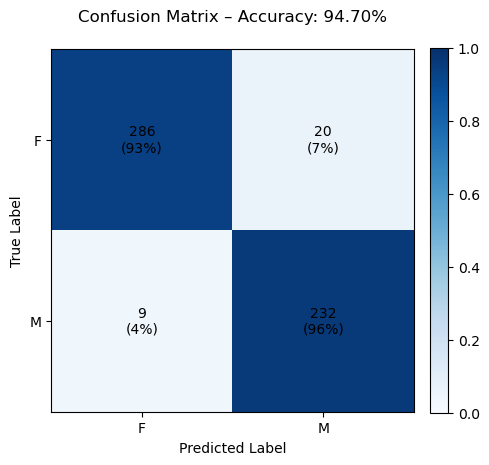

Overall Accuracy (All Predictions):           94.70% (n = 547)
Accuracy (High Confidence only):               98.87% (n = 265)
Accuracy (High + Moderate Confidence):         97.47% (n = 474)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

# === 1) CSV laden ===
file_path = r"C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package_backup/FIT_package/results/data/eurasian_otter_predictions.csv"
df = pd.read_csv(file_path)

# === 2) Spaltennamen ausgeben zum Debug (optional) ===
print("Spalten im DataFrame:", df.columns.tolist())

# === 3) Filter & Mapping ===
# Nur Zeilen mit vorhandener Vorhersage behalten
df = df[df["predicted_sex"].notna()]

# Numeric-Prediction → Buchstaben-Labels (groß)
label_map = {0: "F", 1: "M"}
df["pred_label"] = df["predicted_sex"].astype(int).map(label_map)

# True-Labels aus der Originalspalte, ebenfalls groß
df["true_label"] = df["Sex"].str.upper()

# === 4) Confusion-Matrix-Funktion ===
def get_conf_matrix(y_true, y_pred, labels=["F", "M"]):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = cm.astype(float) / row_sums
        cm_norm[np.isnan(cm_norm)] = 0

    annot = np.empty_like(cm).astype(object)
    for i in range(len(labels)):
        for j in range(len(labels)):
            cnt = cm[i, j]
            pct = int(round(cm_norm[i, j] * 100))
            annot[i, j] = f"{cnt}\n({pct}%)"

    acc = accuracy_score(y_true, y_pred)
    return cm_norm, annot, acc

# === 5) Confusion-Matrix & Accuracy berechnen ===
mask = df["true_label"].isin(["F","M"]) & df["pred_label"].isin(["F","M"])
df_cm = df[mask]
cm, annot, acc = get_conf_matrix(df_cm["true_label"], df_cm["pred_label"])

# === 6) Plot ===
plt.figure(figsize=(5,5))
plt.title(f"Confusion Matrix – Accuracy: {acc:.2%}", pad=20)
im = plt.imshow(cm, vmin=0, vmax=1, cmap="Blues")
plt.colorbar(im, fraction=0.046, pad=0.04)
labels = ["F", "M"]
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, annot[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

# === 7) Prediction Quality einteilen ===
# Maximalwahrscheinlichkeit pro Zeile
df["Max_Prob"] = df[["predicted_proba_f", "predicted_proba_m"]].max(axis=1)

# Quality-Kategorien
def classify_quality(p):
    if p > 0.9:
        return "High Confidence"
    elif p > 0.7:
        return "Moderate Confidence"
    else:
        return "Low Confidence"

df["Prediction Quality"] = df["Max_Prob"].apply(classify_quality)

# Richtig/Falsch markieren
df["Correct"] = df["pred_label"] == df["true_label"]

# === 8) Confidence-Accuracies ausgeben ===
# Nur gültige F/M-Zeilen
df_cm = df[df["true_label"].isin(["F", "M"])]

total     = df_cm
high      = df_cm[df_cm["Prediction Quality"] == "High Confidence"]
high_mod  = df_cm[df_cm["Prediction Quality"].isin(["High Confidence", "Moderate Confidence"])]

acc_total    = total["Correct"].mean()    if len(total)   > 0 else np.nan
acc_high     = high["Correct"].mean()     if len(high)    > 0 else np.nan
acc_high_mod = high_mod["Correct"].mean() if len(high_mod)> 0 else np.nan

print(f"Overall Accuracy (All Predictions):           {acc_total:.2%} (n = {len(total)})")
print(f"Accuracy (High Confidence only):               {acc_high:.2%} (n = {len(high)})")
print(f"Accuracy (High + Moderate Confidence):         {acc_high_mod:.2%} (n = {len(high_mod)})")


C:\Users\Frede\AppData\Local\Temp\ipykernel_2948\2576529738.py:52: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return count_df.applymap(


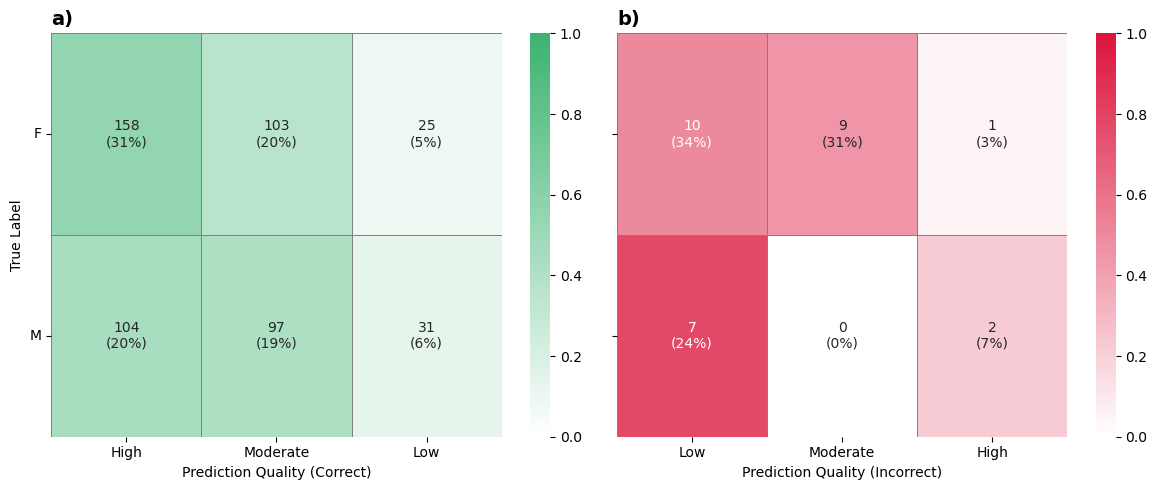

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# === 1) CSV laden ===
file_path = r"C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package_backup/FIT_package/results/data/eurasian_otter_predictions.csv"
df = pd.read_csv(file_path)




C:\Users\Frede\AppData\Local\Temp\ipykernel_2948\2064071758.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trail_quality = df.groupby(["trail", "true_label"]).apply(classify_majority_accuracy).reset_index(name="Class")
C:\Users\Frede\AppData\Local\Temp\ipykernel_2948\2064071758.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  animal_quality = df.groupby(["animal", "true_label"]).apply(classify_majority_accu

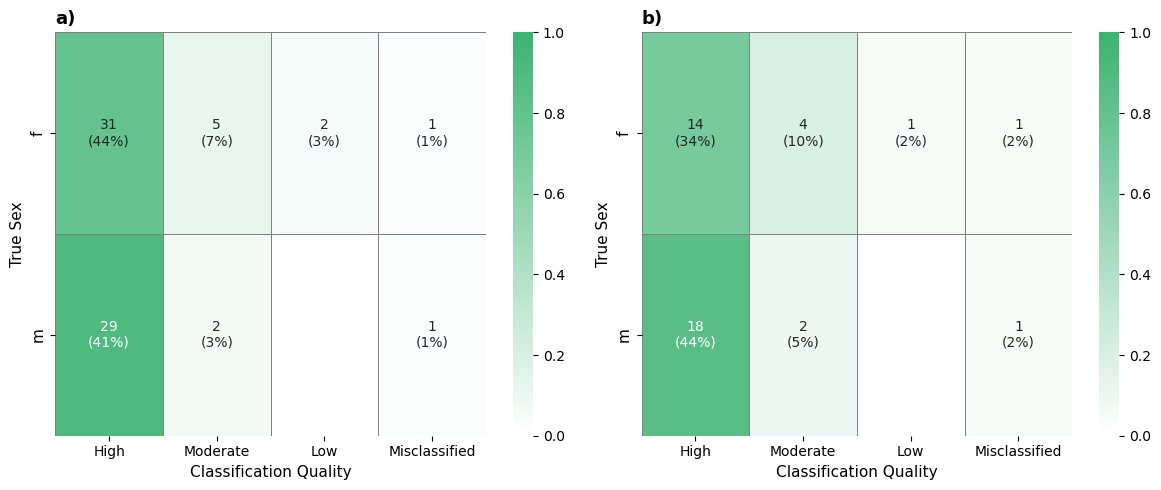

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# === CSV einlesen ===
file_path = r"C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package_backup/FIT_package/results/data/eurasian_otter_predictions.csv"
df = pd.read_csv(file_path)

# === Vorverarbeitung: Labels vereinheitlichen ===
df["true_label"] = df["Sex"].astype(str).str.lower().str.strip()
df["predicted_sex"] = df["predicted_sex"].map({0: "f", 1: "m"})

# === NaNs in true_label entfernen ===
df = df[df["true_label"].isin(["f", "m"])].copy()

# === Correct-Flag berechnen ===
df["Correct"] = df["predicted_sex"] == df["true_label"]

# === Klassifikationsqualität pro Trail bzw. Tier berechnen ===
def classify_majority_accuracy(group):
    acc = group["Correct"].mean()
    if acc >= 0.9:
        return "High"
    elif acc >= 0.7:
        return "Moderate"
    elif acc >= 0.5:
        return "Low"
    else:
        return "Misclassified"

# Individual Level
trail_quality = df.groupby(["trail", "true_label"]).apply(classify_majority_accuracy).reset_index(name="Class")
# Trail Level
animal_quality = df.groupby(["animal", "true_label"]).apply(classify_majority_accuracy).reset_index(name="Class")

# === Gruppieren und Pivot-Tabellen erstellen ===
conf_trail = trail_quality.groupby(["true_label", "Class"]).size().reset_index(name="Count")
conf_animal = animal_quality.groupby(["true_label", "Class"]).size().reset_index(name="Count")

pivot_trail = conf_trail.pivot_table(index="true_label", columns="Class", values="Count", fill_value=0).reindex(columns=["High", "Moderate", "Low", "Misclassified"])
pivot_animal = conf_animal.pivot_table(index="true_label", columns="Class", values="Count", fill_value=0).reindex(columns=["High", "Moderate", "Low", "Misclassified"])

# Fehlende Kombinationen ergänzen
for df_pivot in [pivot_trail, pivot_animal]:
    for sex in ["f", "m"]:
        if sex not in df_pivot.index:
            df_pivot.loc[sex] = 0
    for col in ["High", "Moderate", "Low", "Misclassified"]:
        if col not in df_pivot.columns:
            df_pivot[col] = 0

# === Visualisierung ===
save_path = r"C:\\Users\\Frede\\OneDrive\\Projects and Disschaptors\\FIT in JMP\\PLots for Paper\\heatmaps_majority_classification_trail_and_individual_level_ALL_fixed.png"
green_trail_cmap = LinearSegmentedColormap.from_list("trail_green", ["white", "mediumseagreen"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_labels = ["High", "Moderate", "Low", "Misclassified"]
x_tick_positions = np.arange(len(class_labels)) + 0.5
y_labels = ["f", "m"]
y_tick_positions = np.arange(len(y_labels)) + 0.5

for i, (pivot, title, ax) in enumerate(zip(
    [pivot_trail, pivot_animal],
    ["a)", #Trail level"
     "b)", #Individual Level
     ],
    axes
)):
    pivot = pivot.fillna(0)
    totals = pivot.sum(axis=1)
    proportions = pivot.div(totals, axis=0).fillna(0)
    counts = pivot.astype(int)
    total_sum = counts.sum().sum()

    annot = counts.applymap(lambda val: f"{val}\n({val / total_sum:.0%})" if val > 0 else "")

    sns.heatmap(
        proportions,
        annot=annot,
        fmt='',
        cmap=green_trail_cmap,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor='gray',
        ax=ax,
        cbar=True,
    )
    ax.set_title(title, loc='left', fontsize=13, fontweight='bold')
    ax.set_ylabel("True Sex", fontsize=11)
    ax.set_yticks(y_tick_positions)
    ax.set_yticklabels(y_labels, rotation=90, fontsize=11)
    ax.set_xticks(x_tick_positions)
    ax.set_xticklabels(class_labels)
    ax.set_xlabel("Classification Quality", fontsize=11)

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()


In [14]:
# %% [markdown]
# # Hyperparameter-Analyse-Notebook (inkl. "None" als eigene Klasse & Step-Impact-Analyse)

# %% 
# 1. Daten einlesen & vorbereiten
import os
import pandas as pd
import numpy as np

# Pfad zur CSV mit allen Random-Search-Ergebnissen anpassen
csv_path = r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\random_search_standard_metrics\all_results.csv"
df = pd.read_csv(csv_path)

# Ordner für Plots erstellen
output_dir = r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\figures\sex_model"
os.makedirs(output_dir, exist_ok=True)

# Parameter-Kategorien typisieren (inkl. None als eigener Kategorie-Wert)
cat_params = [
    'select__method', 'outlier__method', 'scale__method',
    'reduce_pre__method', 'reduce_post__method'
]
for p in cat_params:
    df[p] = df[p].fillna('None').astype('category')

# NaNs bei Performance entfernen
df = df.dropna(subset=['balanced_test_acc'])

# Parameterlisten
param_cols = [c for c in df.columns 
              if c.startswith(('select__', 'outlier__', 'scale__', 'reduce_', 'clf__'))]
num_params = ['reduce_pre__n_components', 'reduce_pre__n_neighbors', 'outlier__z_thresh']

# %% 
# 2. Univariate Plots (inkl. None-Klasse)
import seaborn as sns
import matplotlib.pyplot as plt

for p in cat_params:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=p, y='balanced_test_acc', data=df, order=df[p].cat.categories)
    plt.xticks(rotation=45)
    plt.title(f"Balanced Test Accuracy nach {p}")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"boxplot_{p}.png"))
    plt.close()

# %% 
# 3. Step-Impact-Analyse: Boxplots None vs. Any for jeden Step
steps = {
    'select__method': 'Feature Selection',
    'outlier__method': 'Outlier Cleaning',
    'scale__method':   'Scaling',
    'reduce_pre__method':  'DimRed Pre',
    'reduce_post__method': 'DimRed Post'
}

for p, label in steps.items():
    df[f"{p}_applied"] = np.where(df[p] == 'None', 'No', 'Yes')
    plt.figure(figsize=(5,3))
    sns.boxplot(x=f"{p}_applied", y='balanced_test_acc', data=df, order=['No','Yes'])
    plt.title(f"{label}: Schritt angewendet?")
    plt.xlabel('')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"stepimpact_{p}.png"))
    plt.close()

# %% 
# 4. Bivariate Heatmaps / Scatter (wie gehabt)
x_param = 'reduce_pre__n_components'
y_param = 'reduce_post__n_components'

# Heatmap
pivot = df.pivot_table(
    index=x_param,
    columns=y_param,
    values='balanced_test_acc',
    aggfunc='mean'
)
plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")
plt.title(f"Mean Balanced Test Acc: {x_param} vs. {y_param}")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "heatmap_pre_vs_post.png"))
plt.close()

# Scatter mit Farbskala
plt.figure(figsize=(6,4))
sc = plt.scatter(
    df[x_param], df[y_param],
    c=df['balanced_test_acc'], cmap='viridis',
    alpha=0.7, edgecolors='none'
)
plt.colorbar(sc, label='Balanced Test Acc')
plt.xlabel(x_param)
plt.ylabel(y_param)
plt.title("Scatterplot der Top-2 Parameter")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "scatter_pre_vs_post.png"))
plt.close()

# %% 
# 5. Feature-Importance-Analyse via Random Forest auf Binary Step-Features
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

# Erstelle Binär-Matrix für Step-Anwendung + numerische Parameter
bin_cols = [f"{p}_applied" for p in steps]
X_bin = pd.get_dummies(df[bin_cols], drop_first=True)
X_num = df[num_params]
X_rf = pd.concat([X_bin, X_num], axis=1)
y_rf = df['balanced_test_acc']

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_rf, y_rf)

# Importances extrahieren
imp = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=True)

plt.figure(figsize=(6,4))
imp.plot.barh()
plt.title("Step-Applikation & Num-Params Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "step_feature_importance.png"))
plt.close()

# %% 
# 6. Ergebnisliste anzeigen
print("Plots gespeichert in:", output_dir)
for f in sorted(os.listdir(output_dir)):
    print(" -", f)


Plots gespeichert in: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\figures\sex_model
 - boxplot_outlier__method.png
 - boxplot_reduce_post__method.png
 - boxplot_reduce_pre__method.png
 - boxplot_scale__method.png
 - boxplot_select__method.png
 - heatmap_pre_vs_post.png
 - hyperparam_importance.png
 - scatter_outlier__z_thresh.png
 - scatter_pre_vs_post.png
 - scatter_reduce_pre__n_components.png
 - scatter_reduce_pre__n_neighbors.png
 - step_feature_importance.png
 - stepimpact_outlier__method.png
 - stepimpact_reduce_post__method.png
 - stepimpact_reduce_pre__method.png
 - stepimpact_scale__method.png
 - stepimpact_select__method.png


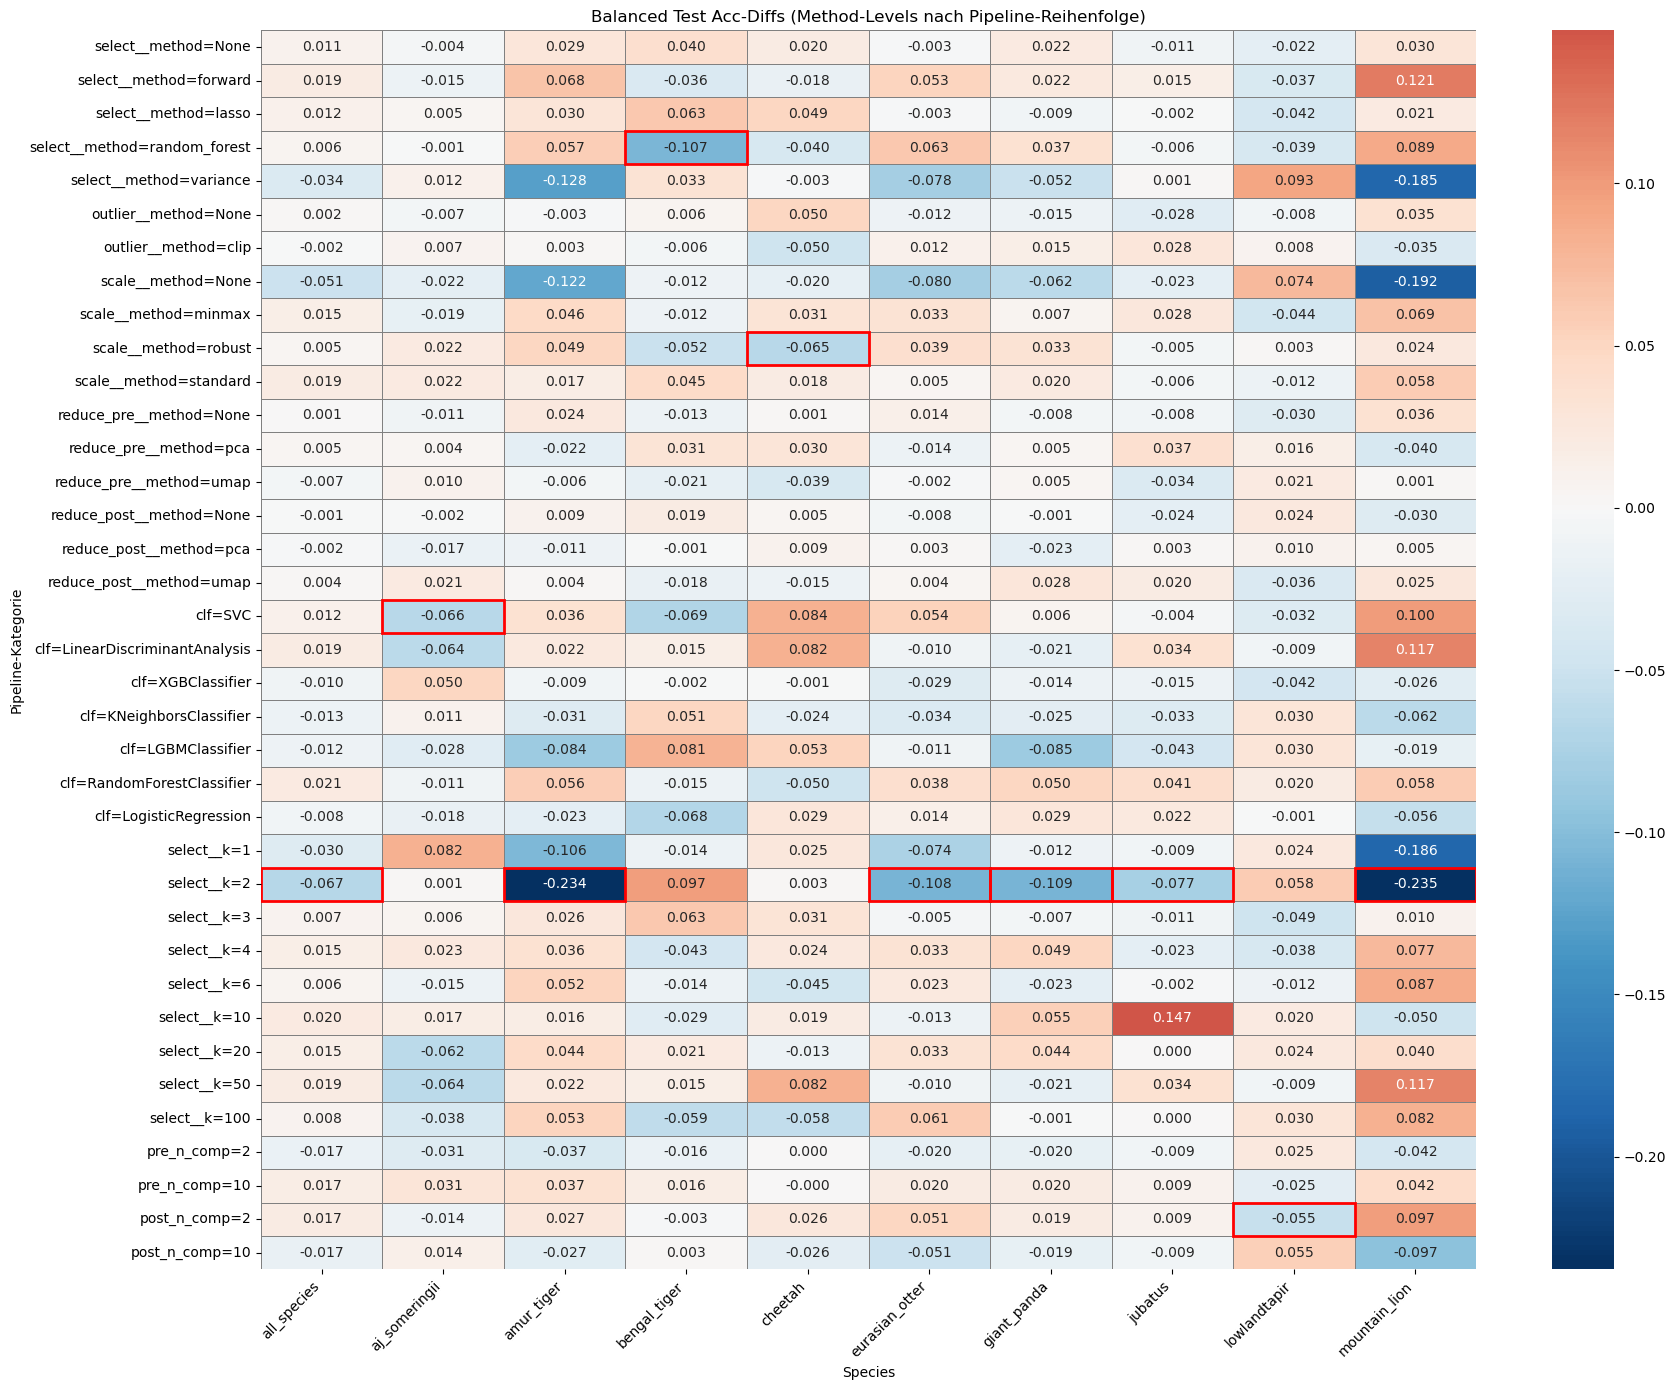

Heatmap mit Low-Highlights gespeichert unter: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\tests\results\data\random_search_standard_metrics\results_plots\combined_cat_levels_min_highlight_ordered.png


In [10]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# 1) Daten einlesen
csv_path = r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\random_search_standard_metrics\all_results.csv"
df = pd.read_csv(csv_path)

# 2) Kategoriale Pipeline-Methoden & Flag-Spalten
method_params = [
    'select__method','outlier__method','scale__method',
    'reduce_pre__method','reduce_post__method'
]
for p in method_params:
    df[p] = df[p].fillna('None').astype('category')
    df[f"{p}_applied"] = (df[p] != 'None').astype(int)

# 3) Classifier-Name extrahieren
df['clf_name'] = df['clf'].astype(str).str.split('(').str[0]

# 4) Index-Reihenfolge definieren
# Erst die Method-Levels in Pipeline-Reihenfolge
pipeline_order = [
    'select__method',
    'outlier__method',
    'scale__method',
    'reduce_pre__method',
    'reduce_post__method'
]
ordered_rows = []
for step in pipeline_order:
    # Für jede Methode alle Level in der vorhandenen Reihenfolge:
    for lvl in df[step].cat.categories:
        ordered_rows.append(f"{step}={lvl}")

# Dann die Classifier
for clf in df['clf_name'].unique():
    ordered_rows.append(f"clf={clf}")

# Dann die Feature-Count-Levels
for k in sorted(df['select__k'].dropna().unique()):
    ordered_rows.append(f"select__k={int(k)}")
for n in sorted(df['reduce_pre__n_components'].dropna().unique()):
    ordered_rows.append(f"pre_n_comp={int(n)}")
for n in sorted(df['reduce_post__n_components'].dropna().unique()):
    ordered_rows.append(f"post_n_comp={int(n)}")

# 5) Leeres DataFrame für die diffs
species = df['species'].unique().tolist()
diff = pd.DataFrame(index=ordered_rows, columns=species, dtype=float)

# 6) Funktion zum Berechnen der Differenz
def compute_diff(mask_col, mask_val):
    return {
        sp: (
            df[(df['species']==sp) & (df[mask_col]==mask_val)]['balanced_test_acc'].mean()
          - df[(df['species']==sp) & (df[mask_col]!=mask_val)]['balanced_test_acc'].mean()
        )
        for sp in species
    }

# 7) Befülle diff in der definierten Reihenfolge
# 7a) Method-Levels
for step in pipeline_order:
    for lvl in df[step].cat.categories:
        row = f"{step}={lvl}"
        diff.loc[row] = compute_diff(step, lvl)

# 7b) Classifier
for clf in df['clf_name'].unique():
        row = f"clf={clf}"
        diff.loc[row] = compute_diff('clf_name', clf)

# 7c) Feature-Count-Levels
for k in sorted(df['select__k'].dropna().unique()):
    row = f"select__k={int(k)}"
    diff.loc[row] = compute_diff('select__k', k)
for n in sorted(df['reduce_pre__n_components'].dropna().unique()):
    row = f"pre_n_comp={int(n)}"
    diff.loc[row] = compute_diff('reduce_pre__n_components', n)
for n in sorted(df['reduce_post__n_components'].dropna().unique()):
    row = f"post_n_comp={int(n)}"
    diff.loc[row] = compute_diff('reduce_post__n_components', n)

# 8) "all_species" als erste Spalte hinzufügen
diff.insert(0, 'all_species', diff.mean(axis=1))

# 9) Heatmap zeichnen & niedrigsten Wert pro Spalte hervorheben
output_dir = r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\tests\results\data\random_search_standard_metrics\results_plots"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(18, 14))
ax = sns.heatmap(
    diff.astype(float),
    annot=True, fmt=".3f",
    cmap="RdBu_r", center=0,
    linewidths=0.5, linecolor="gray"
)

# Roter Rahmen um jeweils den niedrigsten Wert
for j, col in enumerate(diff.columns):
    i_min = diff[col].astype(float).idxmin()
    i = diff.index.get_loc(i_min)
    ax.add_patch(Rectangle((j, i), 1, 1, fill=False, edgecolor='red', lw=2))

ax.set_xlabel("Species")
ax.set_ylabel("Pipeline-Kategorie")
plt.xticks(rotation=45, ha="right")
plt.title("Balanced Test Acc-Diffs (Method-Levels nach Pipeline-Reihenfolge)")
plt.tight_layout()

out_path = os.path.join(output_dir, "combined_cat_levels_min_highlight_ordered.png")
plt.savefig(out_path, dpi=150)
plt.show()

print("Heatmap mit Low-Highlights gespeichert unter:", out_path)


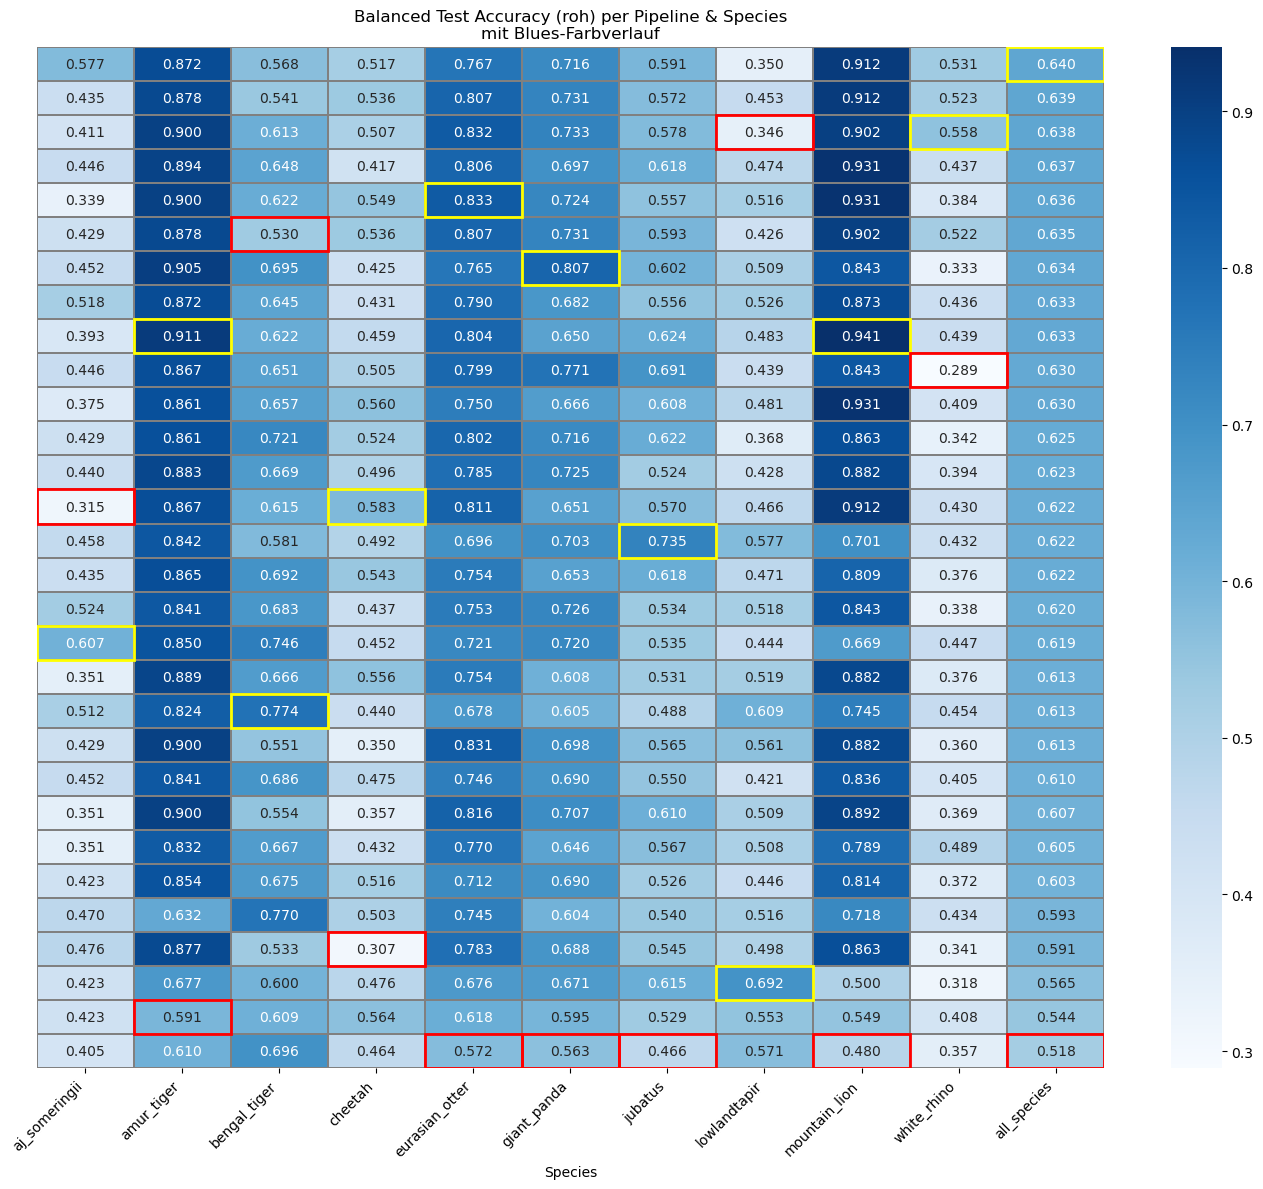

Heatmap für 'balanced_test_acc' gespeichert unter: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\tests\results\data\random_search_standard_metrics\results_plots\heatmap_balanced_test_acc.png



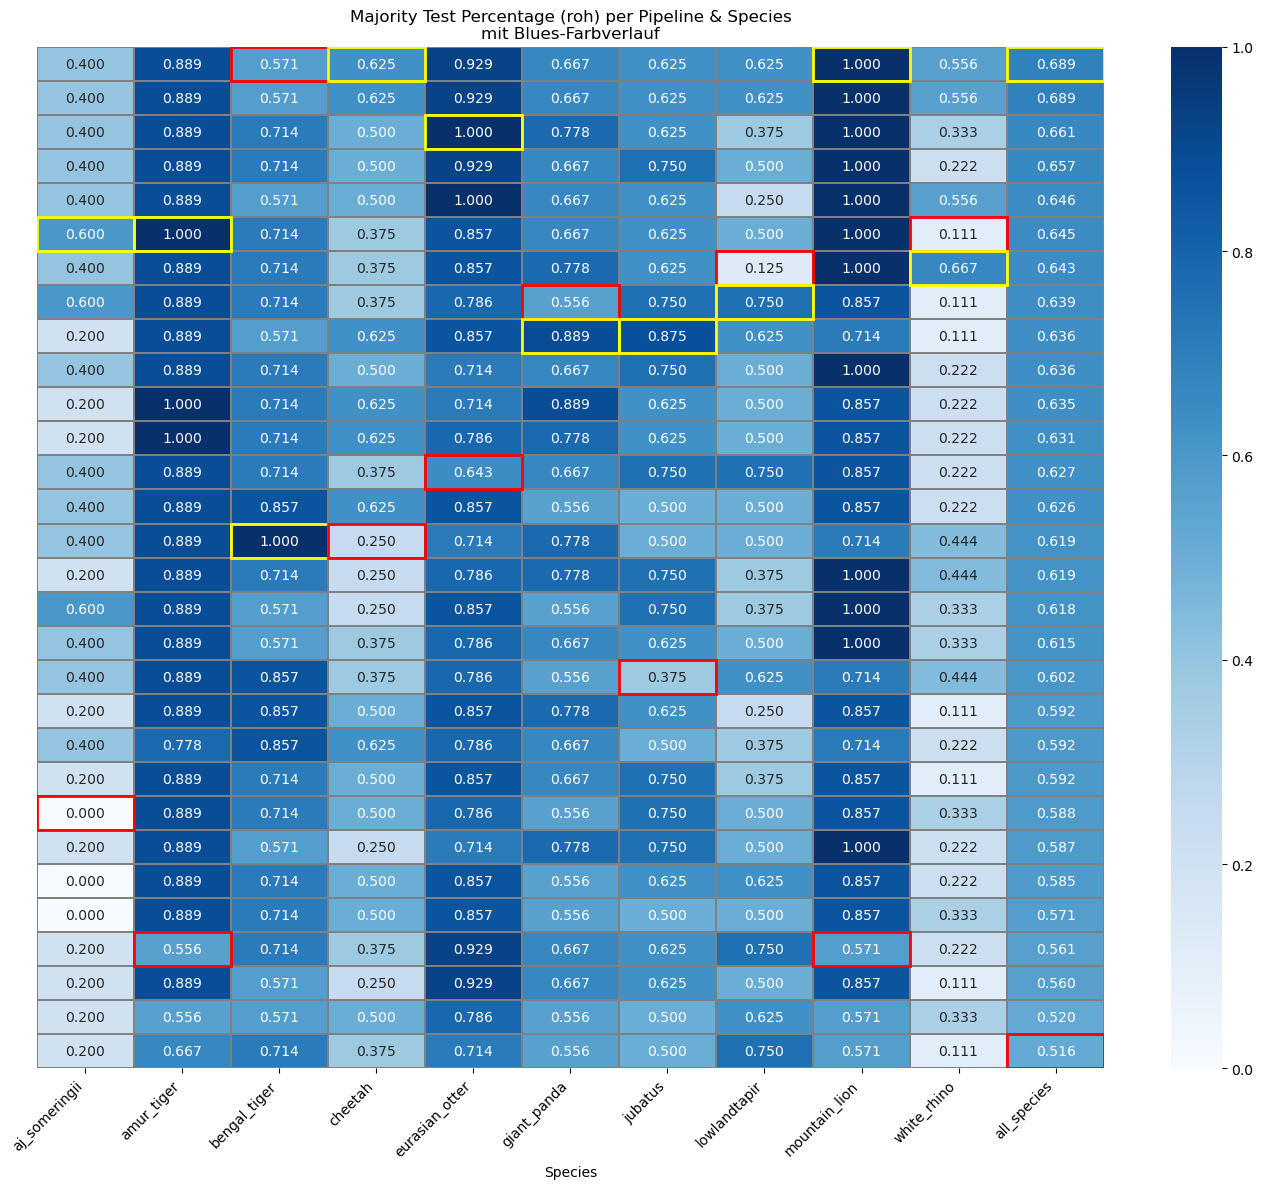

Heatmap für 'maj_test_pct' gespeichert unter: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\tests\results\data\random_search_standard_metrics\results_plots\heatmap_maj_test_pct.png



In [3]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 1) Pfade definieren
csv_path    = r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\random_search_standard_metrics\all_results.csv"
output_dir  = r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\tests\results\data\random_search_standard_metrics\results_plots"
os.makedirs(output_dir, exist_ok=True)

# 2) Daten einlesen
df = pd.read_csv(csv_path)

# 3) Heatmap-Funktion mit einheitlichem Farbschema
def plot_heatmap(metric, cmap="Blues", low_color="red", high_color="yellow"):
    # Pivot-Tabelle
    heat = df.pivot_table(
        index="pipeline_id",
        columns="species",
        values=metric,
        aggfunc="mean"
    )
    # all_species-Spalte und Sortierung
    heat["all_species"] = heat.mean(axis=1)
    heat = heat.sort_values(by="all_species", ascending=False)

    # Plot
    plt.figure(figsize=(14, 12))
    ax = sns.heatmap(
        heat,
        annot=True, fmt=".3f",
        cmap=cmap,
        linewidths=0.3, linecolor="gray",
        yticklabels=False
    )
    plt.ylabel("")
    plt.xlabel("Species")
    title = {
        "balanced_test_acc": "Balanced Test Accuracy (roh)",
        "maj_test_pct":      "Majority Test Percentage (roh)"
    }.get(metric, metric)
    plt.title(f"{title} per Pipeline & Species\nmit {cmap}-Farbverlauf")
    plt.xticks(rotation=45, ha="right")

    # Min in low_color, Max in high_color einrahmen
    for j, col in enumerate(heat.columns):
        vals = heat[col].astype(float)
        # niedrigster Wert
        i_min     = vals.idxmin()
        i_min_idx = heat.index.get_loc(i_min)
        ax.add_patch(Rectangle((j, i_min_idx), 1, 1, fill=False, edgecolor=low_color,  lw=2))
        # höchster Wert
        i_max     = vals.idxmax()
        i_max_idx = heat.index.get_loc(i_max)
        ax.add_patch(Rectangle((j, i_max_idx), 1, 1, fill=False, edgecolor=high_color, lw=2))

    plt.tight_layout()
    out_path = os.path.join(output_dir, f"heatmap_{metric}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Heatmap für '{metric}' gespeichert unter: {out_path}\n")

# 4) Zwei Heatmaps mit demselben Farbschema
plot_heatmap("balanced_test_acc", cmap="Blues", low_color="red",    high_color="yellow")
plot_heatmap("maj_test_pct",      cmap="Blues", low_color="red",    high_color="yellow")
